# Report II

#### Kristian Kirs 242046MASM
#### Ella Maria Raud 242407MASM

## Task 1. Analysis
### Code for Subtask 1.a Read and understand the data.

In [2]:
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the train dataset
train_data = pd.read_csv("train.csv")

# Display basic information
print("Train Dataset Info:")
print(train_data.info())

# Display the first few rows
print("\nFirst few rows of the Train Dataset:")
print(train_data.head())

# Summary statistics for numeric columns
print("\nSummary Statistics:")
print(train_data.describe())

# Check for missing values
print("\nMissing Values:")
print(train_data.isnull().sum())



Train Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8424 entries, 0 to 8423
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    8424 non-null   object 
 1   temp    8424 non-null   float64
 2   dwpt    8424 non-null   float64
 3   rhum    8424 non-null   float64
 4   snow    119 non-null    float64
 5   wdir    8424 non-null   float64
 6   wspd    8424 non-null   float64
 7   wpgt    8424 non-null   float64
 8   pres    8424 non-null   float64
 9   price   8424 non-null   float64
 10  demand  8338 non-null   float64
dtypes: float64(10), object(1)
memory usage: 724.1+ KB
None

First few rows of the Train Dataset:
                        time  temp  dwpt  rhum  snow   wdir  wspd  wpgt  \
0  2021-09-01 00:00:00+03:00  11.2  10.3  94.0   NaN  320.0   7.2  16.7   
1  2021-09-01 01:00:00+03:00  10.7   9.6  93.0   NaN  320.0   7.2  13.0   
2  2021-09-01 02:00:00+03:00   9.9   9.0  94.0   NaN  320.0   7.2  13

### Code for Subtask 1.b (Cleaning the Data)

In [3]:
# Step 1: Convert 'time' column to datetime format
train_data['time'] = pd.to_datetime(train_data['time'])
print("Time column converted to datetime format.")

# Step 2: Interpolate missing values in 'demand' using linear interpolation
train_data['demand'] = train_data['demand'].interpolate(method='linear')
print("Missing values in 'demand' column handled with linear interpolation.")

# Display results
print("\nDataset Info After Cleaning:")
print(train_data.info())
print("\nFirst few rows of the cleaned dataset:")
print(train_data.head())


Time column converted to datetime format.
Missing values in 'demand' column handled with linear interpolation.

Dataset Info After Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8424 entries, 0 to 8423
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    8424 non-null   object 
 1   temp    8424 non-null   float64
 2   dwpt    8424 non-null   float64
 3   rhum    8424 non-null   float64
 4   snow    119 non-null    float64
 5   wdir    8424 non-null   float64
 6   wspd    8424 non-null   float64
 7   wpgt    8424 non-null   float64
 8   pres    8424 non-null   float64
 9   price   8424 non-null   float64
 10  demand  8424 non-null   float64
dtypes: float64(10), object(1)
memory usage: 724.1+ KB
None

First few rows of the cleaned dataset:
                        time  temp  dwpt  rhum  snow   wdir  wspd  wpgt  \
0  2021-09-01 00:00:00+03:00  11.2  10.3  94.0   NaN  320.0   7.2  16.7   
1  2021-09-01 01:00:0

### Subtask 1.c: Provide a Description of the Data

Summary Statistics:
              temp         dwpt         rhum        snow         wdir  \
count  8424.000000  8424.000000  8424.000000  119.000000  8424.000000   
mean      6.435708     2.228359    77.191121   78.319328   202.886633   
std       9.064983     8.053260    17.482734   63.129130    87.841014   
min     -26.100000   -28.700000    20.000000    0.000000     0.000000   
25%       0.300000    -3.000000    66.000000   20.000000   160.000000   
50%       6.000000     1.700000    83.000000   60.000000   210.000000   
75%      12.800000     8.400000    91.000000  130.000000   270.000000   
max      31.400000    20.900000   100.000000  220.000000   360.000000   

              wspd         wpgt         pres        price       demand  
count  8424.000000  8424.000000  8424.000000  8424.000000  8424.000000  
mean      9.132918    20.931588  1013.128063     0.156541     1.054433  
std       4.808481    10.003438    12.693745     0.112922     1.101446  
min       0.000000     2.90000

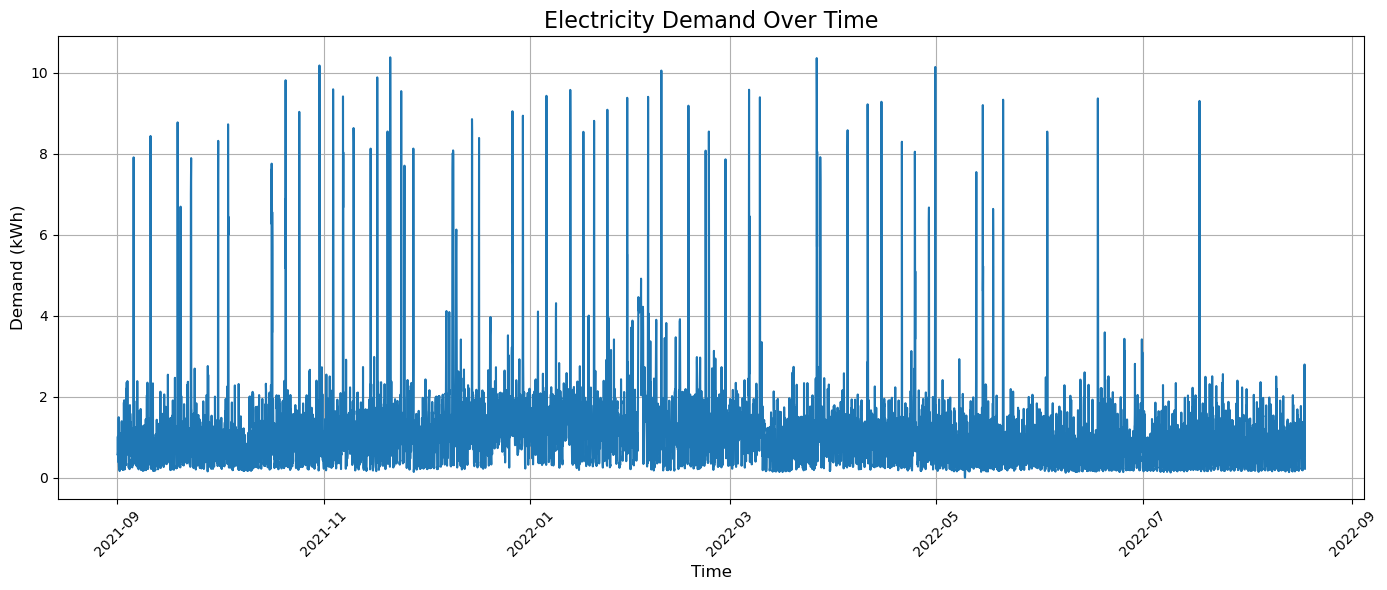

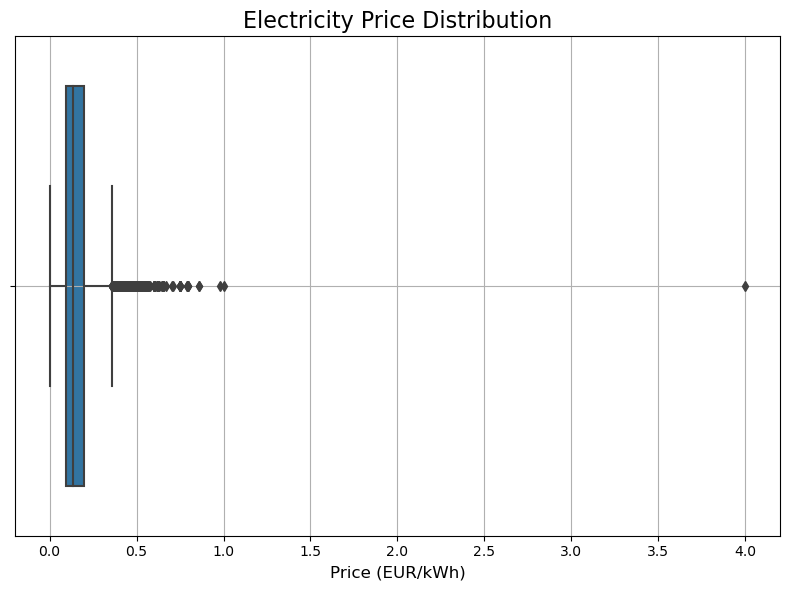

In [4]:
# Step 1: Statistical Summary
print("Summary Statistics:")
print(train_data.describe())

# Step 2: Line Plot for Demand Over Time
plt.figure(figsize=(14, 6))
sns.lineplot(x='time', y='demand', data=train_data)
plt.title("Electricity Demand Over Time", fontsize=16)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Demand (kWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 3: Box Plot for Electricity Price Distribution
plt.figure(figsize=(8, 6))
sns.boxplot(x=train_data['price'])
plt.title("Electricity Price Distribution", fontsize=16)
plt.xlabel("Price (EUR/kWh)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Subtask 1.d: Analyze Distributions of Each Variable (Except demand)

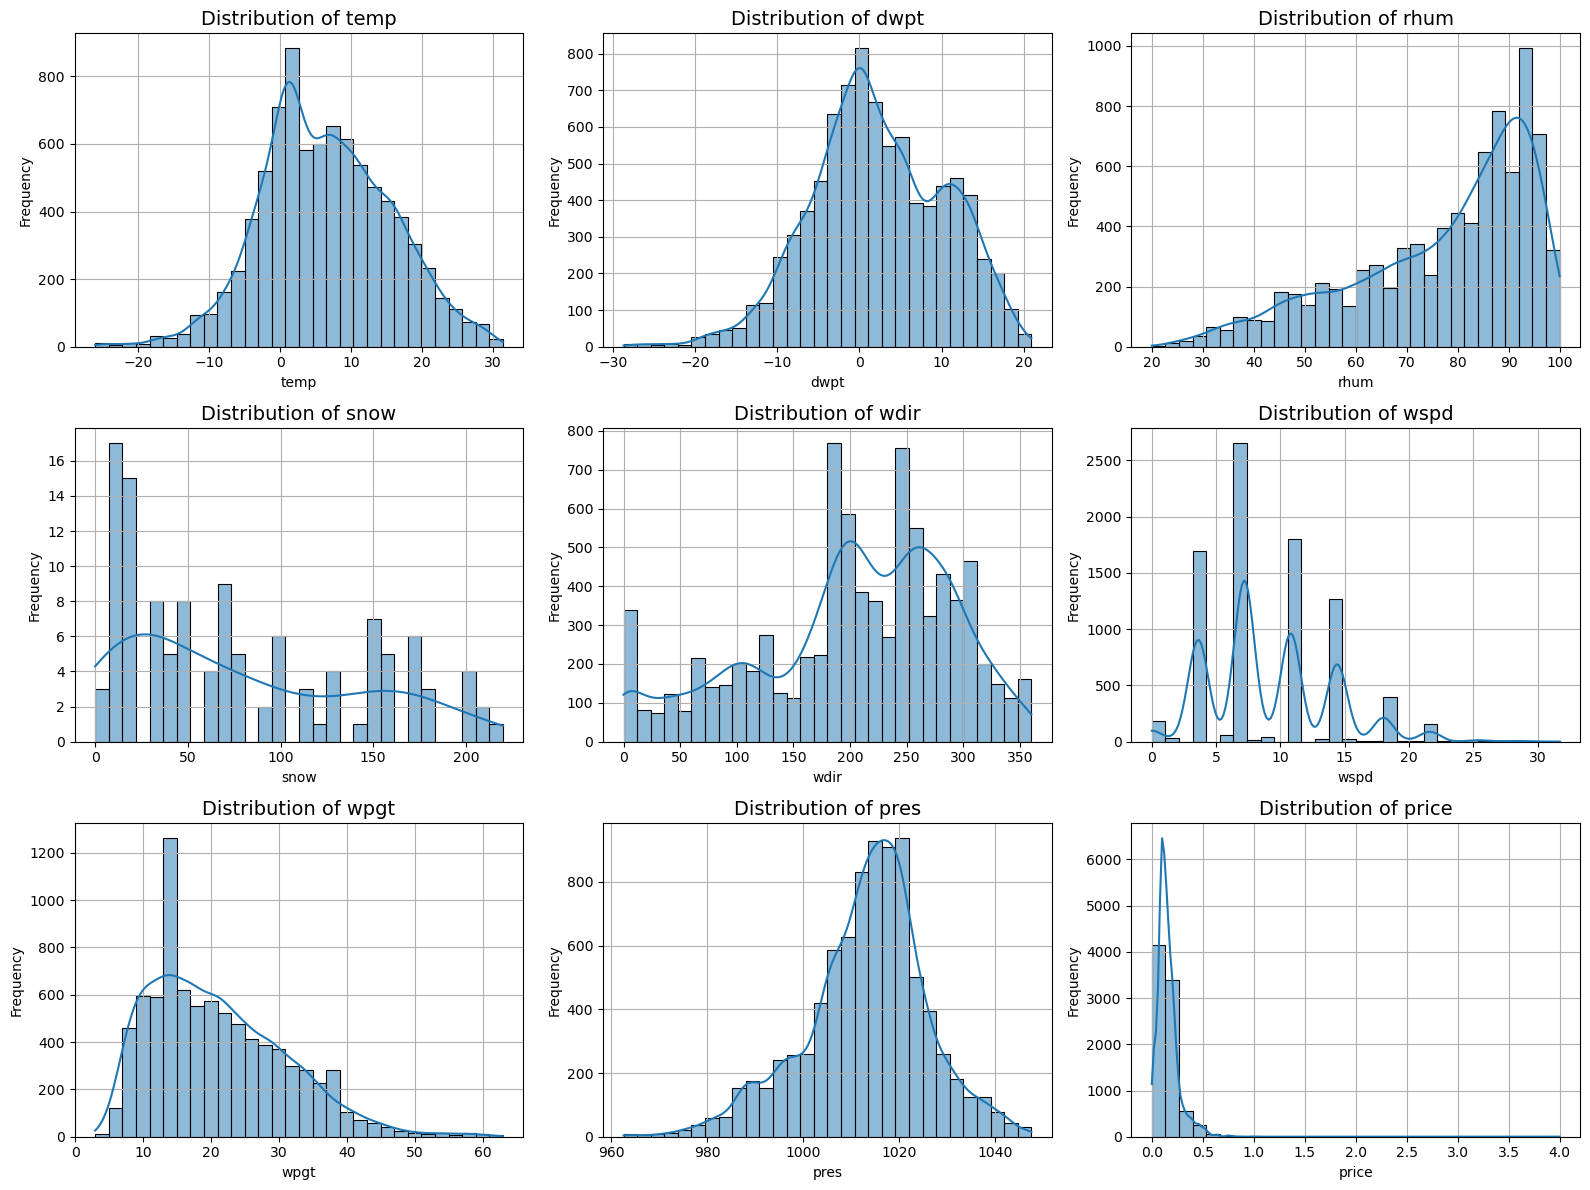

In [5]:
# Variables to analyze (excluding 'demand')
variables_to_analyze = ['temp', 'dwpt', 'rhum', 'snow', 'wdir', 'wspd', 'wpgt', 'pres', 'price']

plt.figure(figsize=(16, 12))
for i, variable in enumerate(variables_to_analyze, 1):
    plt.subplot(3, 3, i)
    sns.histplot(train_data[variable], kde=True, bins=30)
    plt.title(f"Distribution of {variable}", fontsize=14)
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.grid(True)

plt.tight_layout()
plt.show()


#### Apply any relevant transformations

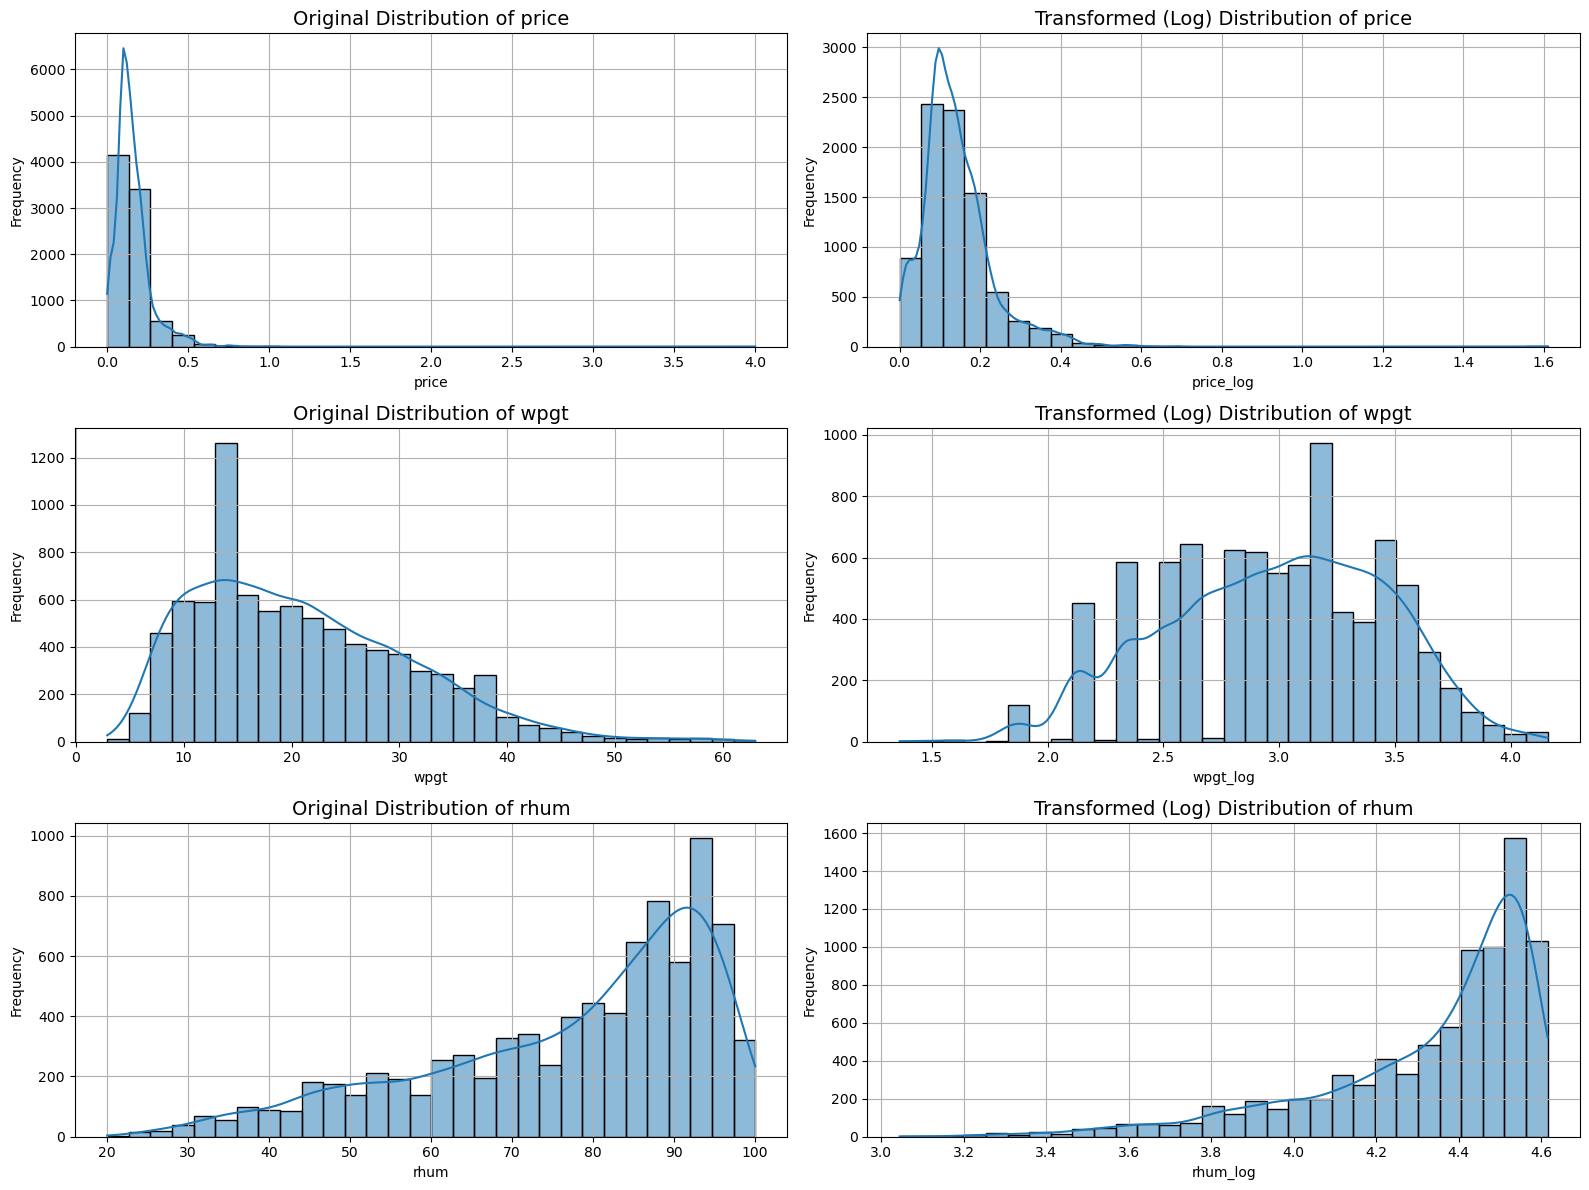

In [6]:
# Variables to transform (based on observed skewness)
variables_to_transform = ['price', 'wpgt', 'rhum']

# Apply log transformation (adding a small constant to avoid log(0))
for variable in variables_to_transform:
    train_data[f'{variable}_log'] = np.log1p(train_data[variable])  # log1p(x) = log(1 + x)

# Plot original vs transformed distributions
plt.figure(figsize=(16, 12))
for i, variable in enumerate(variables_to_transform, 1):
    # Original Distribution
    plt.subplot(3, 2, i * 2 - 1)
    sns.histplot(train_data[variable], kde=True, bins=30)
    plt.title(f"Original Distribution of {variable}", fontsize=14)
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.grid(True)
    
    # Transformed Distribution
    plt.subplot(3, 2, i * 2)
    sns.histplot(train_data[f'{variable}_log'], kde=True, bins=30)
    plt.title(f"Transformed (Log) Distribution of {variable}", fontsize=14)
    plt.xlabel(f'{variable}_log')
    plt.ylabel("Frequency")
    plt.grid(True)

plt.tight_layout()
plt.show()

### Subtask 1.e Feature Engineering

In [14]:
train_data['time_UTC'] = pd.to_datetime(train_data['time'], utc=True)  # Parse as UTC
train_data['unix_timestamp'] = train_data['time_UTC'].astype('int64') // 10**9  # Unix timestamp for reference

# Step 2: Use 'time_UTC' to create time-based features
train_data['hour'] = train_data['time_UTC'].dt.hour
train_data['day_of_week'] = train_data['time_UTC'].dt.dayofweek
train_data['is_weekend'] = train_data['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Step 3: Create Lagged Features for Demand
train_data['demand_lag_1'] = train_data['demand'].shift(1)  # 1-hour lag
train_data['demand_lag_24'] = train_data['demand'].shift(24)  # 24-hour lag

# Step 4: Create Rolling Features for Demand
train_data['demand_rolling_mean_24'] = train_data['demand'].rolling(window=24).mean()
train_data['demand_rolling_max_7d'] = train_data['demand'].rolling(window=24*7).max()

# Step 5: Rank Features by Correlation with Demand
numeric_columns = train_data.select_dtypes(include=[np.number])  # Select only numeric columns
correlation = numeric_columns.corr()['demand'].sort_values(ascending=False)
print("\nFeature Correlation with Demand:")
print(correlation)

# Display the dataset with new features
print("\nFirst few rows with new features:")
print(train_data.head())


Feature Correlation with Demand:
demand                    1.000000
demand_lag_1              0.642175
demand_rolling_mean_24    0.365592
demand_lag_24             0.187437
demand_rolling_max_7d     0.172104
rhum_log                  0.095847
rhum                      0.095131
wpgt                      0.069006
hour                      0.058832
is_weekend                0.051978
wpgt_log                  0.050371
wspd                      0.049230
day_of_week               0.036908
snow                      0.024963
wdir                     -0.011811
pres                     -0.065229
price                    -0.122717
unix_timestamp           -0.133712
price_log                -0.134569
dwpt                     -0.247802
temp                     -0.267757
Name: demand, dtype: float64

First few rows with new features:
                        time  temp  dwpt  rhum  snow   wdir  wspd  wpgt  \
0  2021-09-01 00:00:00+03:00  11.2  10.3  94.0   NaN  320.0   7.2  16.7   
1  2021-09-01 01:

## Task 2. Modelling

### Subtask 2.b Construct and train an autoregressive model. Use any ARMA-family model.
#### Stationarise the data, if necessary.

In [15]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test
result = adfuller(train_data['demand'].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

# Interpretation
if result[1] <= 0.05:
    print("Data is stationary (reject null hypothesis).")
else:
    print("Data is not stationary (fail to reject null hypothesis).")


ADF Statistic: -11.350419858178673
p-value: 1.0027014025482286e-20
Critical Values: {'1%': -3.4311289116379524, '5%': -2.8618842253793035, '10%': -2.5669532263020245}
Data is stationary (reject null hypothesis).


#### ACF and PACF Plots

<Figure size 1200x600 with 0 Axes>

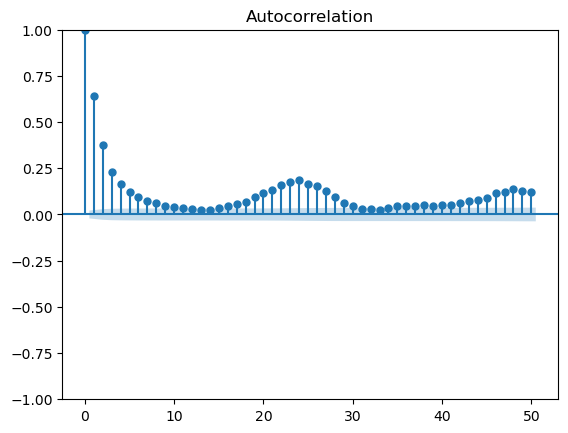

<Figure size 1200x600 with 0 Axes>

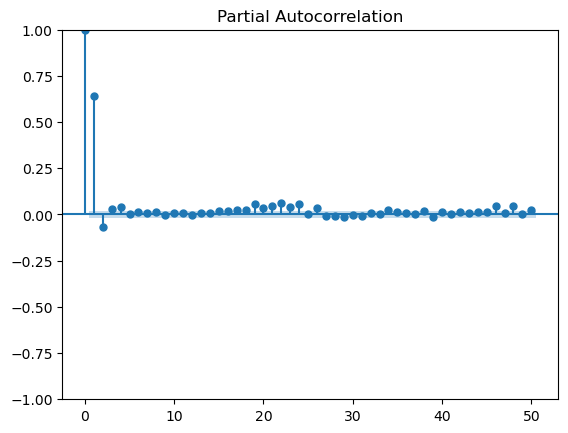

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF and PACF plots
plt.figure(figsize=(12, 6))
plot_acf(train_data['demand'].dropna(), lags=50)
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(train_data['demand'].dropna(), lags=50)
plt.show()


#### ARIMA Model Construction and Training

In [18]:
from statsmodels.tsa.arima.model import ARIMA

# Define the ARIMA model based on ACF/PACF results
model = ARIMA(train_data['demand'], order=(1, 0, 1))  # Replace p, d, q based on plots
model_fit = model.fit()

# Model summary
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:                 8424
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -10508.154
Date:                Wed, 08 Jan 2025   AIC                          21024.307
Time:                        15:55:01   BIC                          21052.463
Sample:                             0   HQIC                         21033.920
                               - 8424                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0541      0.036     29.265      0.000       0.984       1.125
ar.L1          0.5796      0.008     76.080      0.000       0.565       0.594
ma.L1          0.1068      0.009     11.395      0.0

#### Evaluate the Model Using MAE

Mean Absolute Error (MAE): 0.5123705644519194


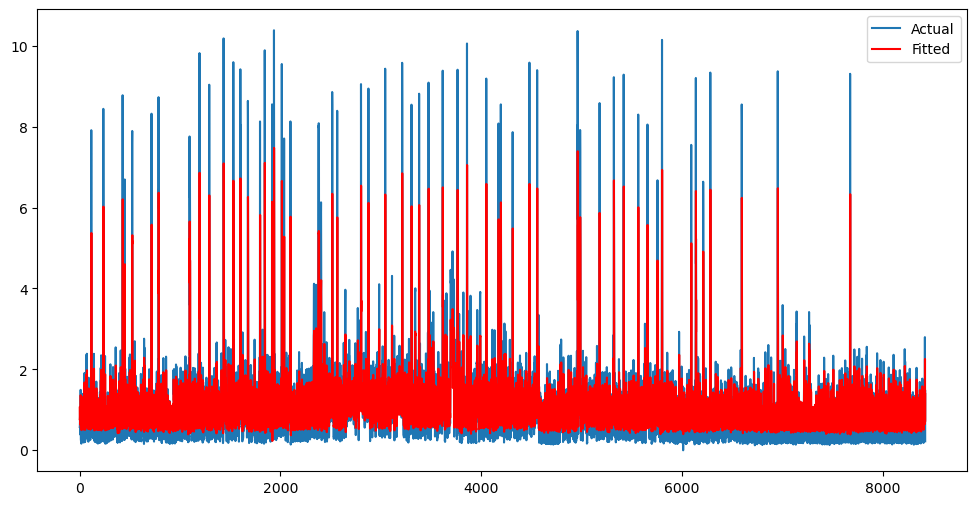

In [19]:
from sklearn.metrics import mean_absolute_error

# Make predictions
train_data['fitted'] = model_fit.fittedvalues
mae = mean_absolute_error(train_data['demand'].dropna(), train_data['fitted'].dropna())
print("Mean Absolute Error (MAE):", mae)

# Plot actual vs fitted values
plt.figure(figsize=(12, 6))
plt.plot(train_data['demand'], label="Actual")
plt.plot(train_data['fitted'], label="Fitted", color='red')
plt.legend()
plt.show()


### Seasonal Decomposition

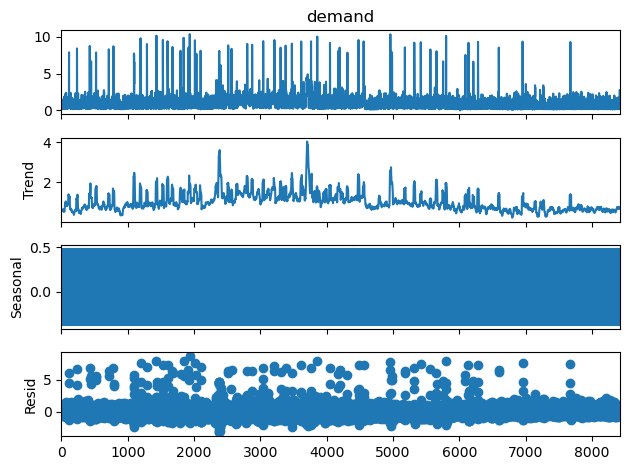

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition
decomposition = seasonal_decompose(train_data['demand'].dropna(), model='additive', period=24)  # Daily seasonality
decomposition.plot()
plt.show()

#### SARIMA Model Training

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define the SARIMA model
seasonal_order = (1, 1, 1, 24)  # P, D, Q, s (24-hour seasonality)
model_sarima = SARIMAX(train_data['demand'], order=(1, 0, 1), seasonal_order=seasonal_order)
model_sarima_fit = model_sarima.fit()

# Model summary
print(model_sarima_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                             demand   No. Observations:                 8424
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -10332.026
Date:                            Wed, 08 Jan 2025   AIC                          20674.051
Time:                                    16:05:23   BIC                          20709.231
Sample:                                         0   HQIC                         20686.063
                                           - 8424                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5103      0.008     65.566      0.000       0.495       0.526
ma.L1          0.1387      0.010   

#### Evaluate the SARIMA Model

SARIMA Mean Absolute Error (MAE): 0.48800200532780197


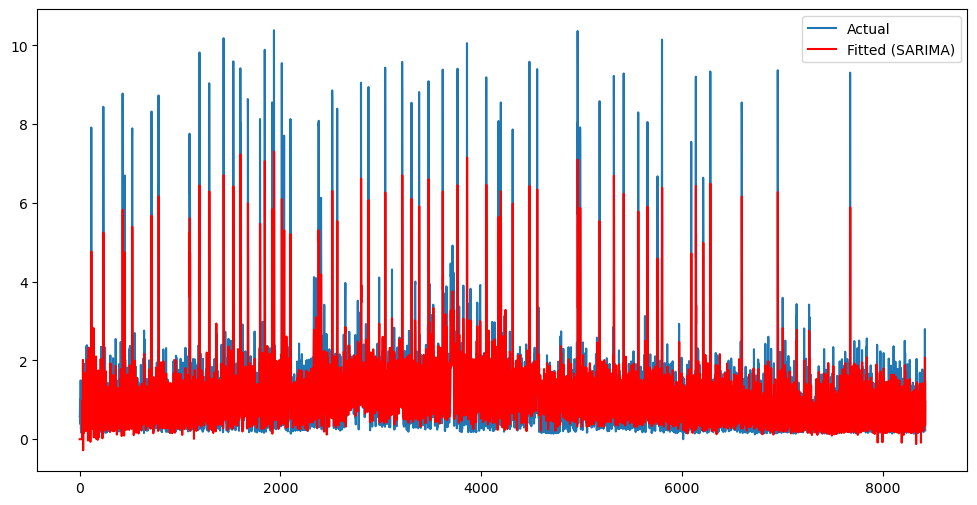

In [22]:
# Predictions and MAE
train_data['fitted_sarima'] = model_sarima_fit.fittedvalues
mae_sarima = mean_absolute_error(train_data['demand'].dropna(), train_data['fitted_sarima'].dropna())
print("SARIMA Mean Absolute Error (MAE):", mae_sarima)

# Plot actual vs fitted values
plt.figure(figsize=(12, 6))
plt.plot(train_data['demand'], label="Actual")
plt.plot(train_data['fitted_sarima'], label="Fitted (SARIMA)", color='red')
plt.legend()
plt.show()

### Task 2.c Construct and train a model using at most three additional features (exogeneous inputs, not lags)

In [23]:
# Select exogenous features
exog_features = ['temp', 'hour', 'is_weekend']
exog_data = train_data[exog_features].dropna()

# Ensure demand data matches the shape of exogenous features
demand_data = train_data['demand'].iloc[exog_data.index]


#### Train the SARIMAX Model

In [24]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define and fit the SARIMAX model
model_sarimax = SARIMAX(demand_data, exog=exog_data, order=(1, 0, 1), seasonal_order=(1, 1, 1, 24))
model_sarimax_fit = model_sarimax.fit()

# Print model summary
print(model_sarimax_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                             demand   No. Observations:                 8424
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -10290.880
Date:                            Wed, 08 Jan 2025   AIC                          20597.760
Time:                                    16:18:38   BIC                          20654.048
Sample:                                         0   HQIC                         20616.979
                                           - 8424                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp          -0.0334      0.004     -8.245      0.000      -0.041      -0.025
hour        4.766e-07   1.19e+04   

SARIMAX Mean Absolute Error (MAE): 0.4832968982886446


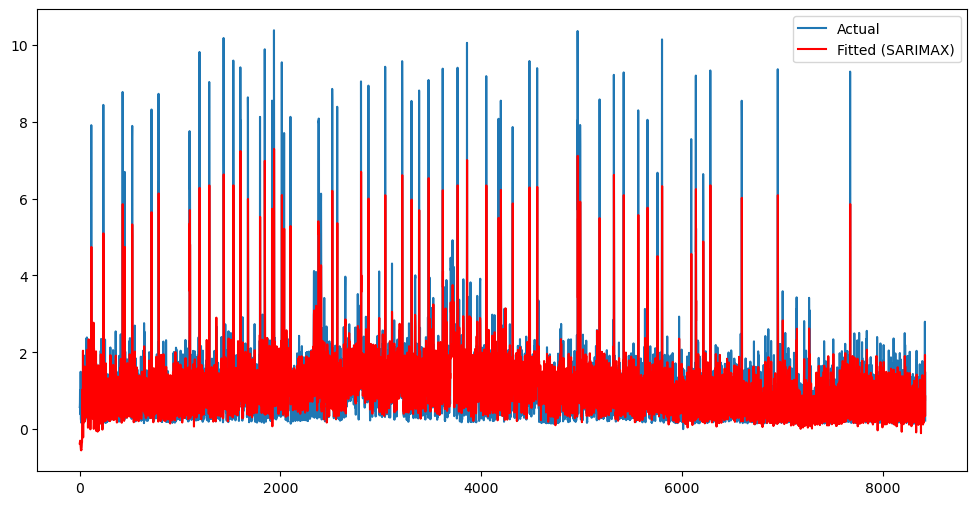

In [25]:
from sklearn.metrics import mean_absolute_error

# Predictions and MAE
fitted_sarimax = model_sarimax_fit.fittedvalues
mae_sarimax = mean_absolute_error(demand_data, fitted_sarimax)
print("SARIMAX Mean Absolute Error (MAE):", mae_sarimax)

# Plot actual vs fitted values
plt.figure(figsize=(12, 6))
plt.plot(demand_data, label="Actual")
plt.plot(fitted_sarimax, label="Fitted (SARIMAX)", color='red')
plt.legend()
plt.show()


In [30]:
# Update exogenous features
exog_features_refined = ['temp', 'is_weekend', 'rhum_log']
exog_data_refined = train_data[exog_features_refined].dropna()

# Ensure demand data matches the shape of exogenous features
demand_data_refined = train_data['demand'].iloc[exog_data_refined.index]

# Define and fit the refined SARIMAX model
model_sarimax_refined = SARIMAX(demand_data_refined, exog=exog_data_refined, order=(1, 0, 1), seasonal_order=(1, 1, 1, 24))
model_sarimax_refined_fit = model_sarimax_refined.fit()

# Print refined model summary
print(model_sarimax_refined_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                             demand   No. Observations:                 8424
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -10289.044
Date:                            Wed, 08 Jan 2025   AIC                          20594.088
Time:                                    16:34:46   BIC                          20650.376
Sample:                                         0   HQIC                         20613.308
                                           - 8424                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp          -0.0318      0.004     -7.806      0.000      -0.040      -0.024
is_weekend     0.1048      0.042   

Refined SARIMAX Mean Absolute Error (MAE): 0.481246693423002


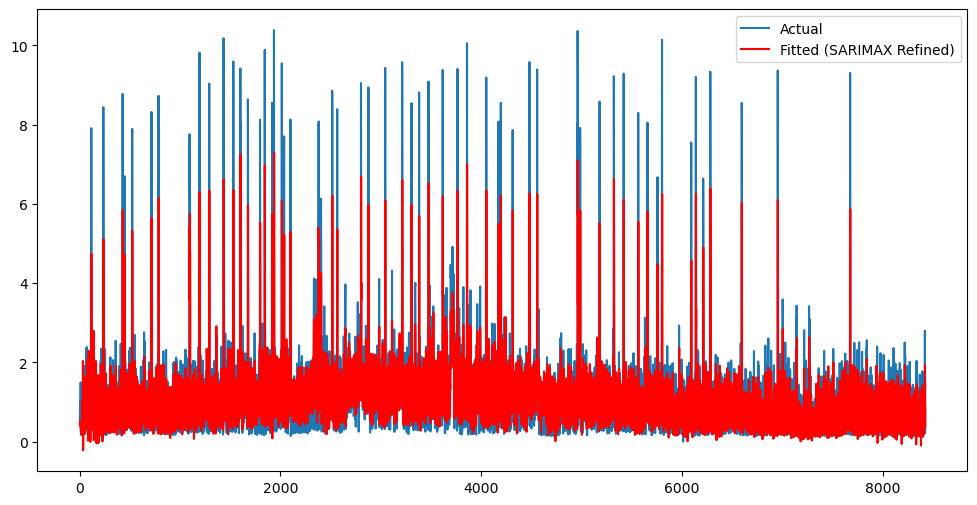

In [56]:
from sklearn.metrics import mean_absolute_error

# Predictions and MAE
fitted_sarimax_refined = model_sarimax_refined_fit.fittedvalues
mae_sarimax_refined = mean_absolute_error(demand_data_refined, fitted_sarimax_refined)
print("Refined SARIMAX Mean Absolute Error (MAE):", mae_sarimax_refined)

# Plot actual vs fitted values
plt.figure(figsize=(12, 6))
plt.plot(demand_data_refined, label="Actual")
plt.plot(fitted_sarimax_refined, label="Fitted (SARIMAX Refined)", color='red')
plt.legend()
plt.savefig('high_quality_plot6.png', dpi=300, format='png', bbox_inches='tight')
plt.show()


## Task 3. Forecasting
### Task 3.a Provide an out-of-sample forecast of hourly demand for all 7 days. Work with dataset from test.csv file

#### Load the Test Dataset and Prepare Inputs

In [33]:
# Load the test dataset
test_data = pd.read_csv("test.csv")
test_data['time_UTC'] = pd.to_datetime(test_data['time'], utc=True)
test_data['hour'] = test_data['time_UTC'].dt.hour
test_data['is_weekend'] = test_data['time_UTC'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# Exogenous features for test data
test_data['rhum_log'] = np.log(test_data['rhum'] + 1)  # Ensure no log(0)
exog_test = test_data[['temp', 'hour', 'is_weekend', 'rhum_log']].dropna()


#### Rolling Forecast with SARIMAX

In [34]:

# Initialize variables
forecast_horizon = 24
rolling_forecast = []
actuals = []

# Loop through each day in the test dataset
for start in range(0, len(exog_test), forecast_horizon):
    # Train on available data (up to the start of the forecast)
    train_subset = train_data['demand']
    exog_train_subset = train_data[['temp', 'hour', 'is_weekend', 'rhum_log']]
    
    # Subset test data for the next 24-hour horizon
    test_subset = test_data['demand'][start:start + forecast_horizon]
    exog_test_subset = exog_test[start:start + forecast_horizon]

    # Train SARIMAX model
    model_sarimax = SARIMAX(train_subset, exog=exog_train_subset, order=(1, 0, 1), seasonal_order=(1, 1, 1, 24))
    model_sarimax_fit = model_sarimax.fit(disp=False)
    
    # Forecast the next 24 hours
    forecast = model_sarimax_fit.forecast(steps=forecast_horizon, exog=exog_test_subset)
    rolling_forecast.extend(forecast)
    actuals.extend(test_subset)

# Evaluate performance
mae_sarimax = mean_absolute_error(actuals, rolling_forecast)
print("SARIMAX Rolling Forecast MAE:", mae_sarimax)


SARIMAX Rolling Forecast MAE: 0.36555970684655364


#### Naïve Forecasting (Baseline)

In [54]:
# Naïve Forecast: Use the last observed value to predict the next day
naive_forecast = []
for start in range(0, len(test_data), forecast_horizon):
    last_observed = test_data['demand'][start - 1] if start > 0 else train_data['demand'].iloc[-1]
    forecast = [last_observed] * forecast_horizon
    naive_forecast.extend(forecast)

# Evaluate Naïve Forecast
mae_naive = mean_absolute_error(test_data['demand'], naive_forecast)
print("Naïve Forecast MAE:", mae_naive)


Naïve Forecast MAE: 0.4348392857142857


#### Visualisation

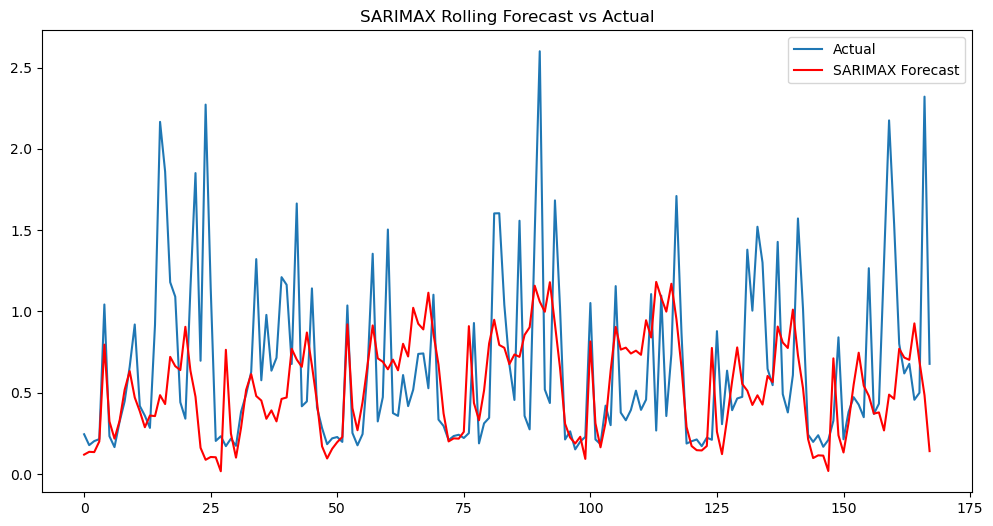

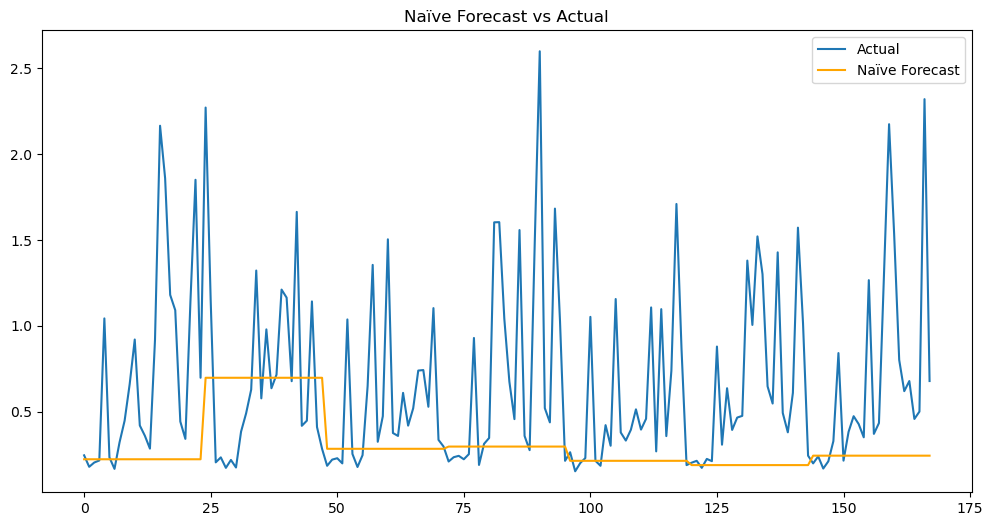

In [55]:
# Plot Actual vs. Forecasted for SARIMAX
plt.figure(figsize=(12, 6))
plt.plot(actuals, label="Actual")
plt.plot(rolling_forecast, label="SARIMAX Forecast", color='red')
plt.legend()
plt.title("SARIMAX Rolling Forecast vs Actual")
plt.savefig('high_quality_plot4.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

# Plot Actual vs. Naïve Forecast
plt.figure(figsize=(12, 6))
plt.plot(test_data['demand'], label="Actual")
plt.plot(naive_forecast, label="Naïve Forecast", color='orange')
plt.legend()
plt.title("Naïve Forecast vs Actual")
plt.savefig('high_quality_plot5.png', dpi=300, format='png', bbox_inches='tight')
plt.show()


#### Other simple techniques